# Notebook 02 — ทำความเข้าใจข้อมูล Radiosonde Sounding และการตรวจสอบคุณภาพข้อมูล

**รายวิชา:** บรรยากาศและคุณภาพอากาศ / Atmosphere and Air Quality  
**ระดับ:** นิสิตสิ่งแวดล้อม ชั้นปีที่ 3–4  
**สถานี:** Chiang Mai — WMO ID **48327**  
**ช่วงข้อมูล:** 1 มีนาคม–30 เมษายน 2024  
**เวลาสังเกตการณ์:** **00 UTC = 07:00 ICT**  
**จำนวน sounding:** **61 วัน**

---

## ความต่อเนื่องจาก Notebook 01

Notebook 01:

`01_get_ChiangMai_sounding_from_GitHub.ipynb`

ได้ทำหน้าที่

- ดาวน์โหลดข้อมูลจาก GitHub
- ตรวจสอบ station/time/date range
- ตรวจว่ามี 61 soundings
- สร้าง analysis-ready dataset

ไฟล์ที่ Notebook นี้จะอ่านคือ

```text
/content/drive/MyDrive/Teaching_Sounding_AirQuality/
01_data/chiangmai_48327_00UTC_20240301_20240430.csv.gz
```

---

# วัตถุประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. อธิบายโครงสร้างของข้อมูล radiosonde sounding ได้
2. อธิบายความหมายของ pressure, height, temperature, dew point, RH, mixing ratio และ wind
3. อธิบายความหมายพื้นฐานของ potential temperature (\(\theta\)) และ equivalent potential temperature (\(\theta_e\))
4. ตรวจสอบ missing values และปัญหาเชิงโครงสร้างของ vertical profile
5. แสดง vertical profiles ของตัวแปรอุตุนิยมวิทยา
6. เปรียบเทียบ sounding หลายวันอย่างเป็นระบบ
7. เชื่อมโยง vertical atmospheric structure กับประเด็นคุณภาพอากาศเบื้องต้น

> Notebook นี้ยังไม่เน้นการคำนวณ CAPE/CIN หรือการวิเคราะห์ Skew-T  
> หัวข้อเหล่านั้นจะอยู่ใน Notebook 03

# 2.1 Radiosonde วัดอะไร?

Radiosonde เป็นเครื่องมือที่ติดกับบอลลูนตรวจอากาศและวัดสภาพบรรยากาศในแนวดิ่งขณะบอลลูนลอยสูงขึ้น

ตัวแปรหลักที่ใช้ในชุดข้อมูลนี้ประกอบด้วย:

| Variable | ความหมาย | หน่วย |
|---|---|---|
| `pressure_hPa` | ความกดอากาศ | hPa |
| `height_m` | geopotential height | m |
| `temperature_C` | อุณหภูมิอากาศ | °C |
| `dewpoint_C` | อุณหภูมิจุดน้ำค้าง | °C |
| `relative_humidity_pct` | ความชื้นสัมพัทธ์ | % |
| `mixing_ratio_gkg` | อัตราส่วนผสมไอน้ำ | g kg⁻¹ |
| `wind_direction_deg` | ทิศทางลม | degree |
| `wind_speed_ms` | ความเร็วลม | m s⁻¹ |
| `theta_K` | potential temperature | K |
| `theta_e_K` | equivalent potential temperature | K |
| `theta_v_K` | virtual potential temperature | K |

---

## หลักการสำคัญ

หนึ่ง sounding มีข้อมูลหลายระดับ

ดังนั้น

\[
1\ sounding \neq 1\ row
\]

แต่เป็น

\[
1\ sounding = many\ vertical\ levels
\]

เช่น sounding วันที่ 15 มีนาคม อาจประกอบด้วยข้อมูลตั้งแต่ใกล้พื้นจนถึงระดับหลายสิบกิโลเมตร

In [1]:
# ================================================================
# CELL 1 — Mount Google Drive
# ================================================================
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [2]:
# ================================================================
# CELL 2 — Imports and course paths
# ================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(
    "/content/drive/MyDrive/Teaching_Sounding_AirQuality"
)

DATA_DIR = BASE_DIR / "01_data"
META_DIR = BASE_DIR / "02_metadata"
OUTPUT_DIR = BASE_DIR / "03_output"
FIG_DIR = BASE_DIR / "04_figures"

DATA_FILE = (
    DATA_DIR
    / "chiangmai_48327_00UTC_20240301_20240430.csv.gz"
)

for folder in [
    DATA_DIR,
    META_DIR,
    OUTPUT_DIR,
    FIG_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Expected teaching dataset:")
print(DATA_FILE)

Expected teaching dataset:
/content/drive/MyDrive/Teaching_Sounding_AirQuality/01_data/chiangmai_48327_00UTC_20240301_20240430.csv.gz


# 2.2 ตรวจว่าได้รัน Notebook 01 แล้วหรือยัง

Notebook นี้ **ไม่ดาวน์โหลดข้อมูลจาก GitHub ซ้ำ**

เหตุผลคือเราต้องการให้ workflow มีลักษณะ

```text
Notebook 01
Download + Validate + Prepare
        ↓
Notebook 02
Understand + QC + Profiles
        ↓
Notebook 03
Skew-T + Thermodynamics
```

ถ้าไม่พบไฟล์ข้อมูล ให้กลับไปรัน Notebook 01 ก่อน

In [3]:
# ================================================================
# CELL 3 — Check input dataset
# ================================================================
if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Teaching dataset not found.\n"
        "Please run 01_get_ChiangMai_sounding_from_GitHub.ipynb first.\n"
        f"Expected file:\n{DATA_FILE}"
    )

print("Dataset found: OK")

print(
    "File size (MB):",
    round(
        DATA_FILE.stat().st_size
        / (1024 ** 2),
        3
    )
)

Dataset found: OK
File size (MB): 0.113


In [4]:
# ================================================================
# CELL 4 — Read the teaching dataset
# ================================================================
df = pd.read_csv(
    DATA_FILE,
    compression="gzip"
)

df["station_id"] = (
    df["station_id"]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df["launch_datetime_utc"] = pd.to_datetime(
    df["launch_datetime_utc"],
    errors="coerce"
)

df["launch_datetime_ict"] = pd.to_datetime(
    df["launch_datetime_ict"],
    errors="coerce"
)

print("Dataset shape:")
print(df.shape)

print("\nNumber of soundings:")
print(
    df["launch_datetime_utc"]
    .nunique()
)

print("\nDate range:")
print(
    df["launch_datetime_utc"].min()
)
print(
    df["launch_datetime_utc"].max()
)

print("\nFirst 10 rows:")
display(
    df.head(10)
)

Dataset shape:
(4690, 20)

Number of soundings:
61

Date range:
2024-03-01 00:00:00
2024-04-30 00:00:00

First 10 rows:


,station_id,launch_datetime_utc,launch_datetime_ict,hour_utc,hour_ict,pressure_hPa,height_m,temperature_C,dewpoint_C,relative_humidity_pct,mixing_ratio_gkg,wind_direction_deg,wind_speed_source,wind_speed_source_unit,wind_speed_ms,theta_K,theta_e_K,theta_v_K,source_file,source_archive
0,48327,2024-03-01,2024-03-01 07:00:00,0,7,1000.0,314.0,20.8,19.8,94.0,14.68,0.0,0.0,m/s,0.0,293.9,336.0,296.5,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
1,48327,2024-03-01,2024-03-01 07:00:00,0,7,968.0,597.0,22.4,14.4,61.0,10.71,NaN,NaN,m/s,NaN,298.3,329.7,300.2,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
2,48327,2024-03-01,2024-03-01 07:00:00,0,7,962.0,651.0,23.0,15.0,61.0,11.21,NaN,NaN,m/s,NaN,299.4,332.5,301.5,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
3,48327,2024-03-01,2024-03-01 07:00:00,0,7,957.0,696.0,23.6,14.6,57.0,10.98,NaN,NaN,m/s,NaN,300.5,333.0,302.5,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
4,48327,2024-03-01,2024-03-01 07:00:00,0,7,951.0,751.0,24.0,14.0,54.0,10.62,NaN,NaN,m/s,NaN,301.4,333.0,303.4,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
5,48327,2024-03-01,2024-03-01 07:00:00,0,7,946.0,798.0,24.4,13.4,50.0,10.26,NaN,NaN,m/s,NaN,302.3,333.0,304.2,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
6,48327,2024-03-01,2024-03-01 07:00:00,0,7,940.0,853.0,24.6,12.6,47.0,9.79,NaN,NaN,m/s,NaN,303.1,332.5,304.8,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
7,48327,2024-03-01,2024-03-01 07:00:00,0,7,935.0,900.0,25.0,11.0,41.0,8.85,NaN,NaN,m/s,NaN,303.9,330.7,305.6,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
8,48327,2024-03-01,2024-03-01 07:00:00,0,7,930.0,947.0,25.0,10.0,39.0,8.31,NaN,NaN,m/s,NaN,304.4,329.6,305.9,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...
9,48327,2024-03-01,2024-03-01 07:00:00,0,7,925.0,994.0,25.2,10.2,39.0,8.47,NaN,NaN,m/s,NaN,305.1,330.8,306.6,sounding_48327_2024-03-01_00Z.csv,University of Wyoming Atmospheric Science Radi...


# 2.3 Data Dictionary และความหมายทางกายภาพ

## Pressure

ความกดอากาศลดลงเมื่อความสูงเพิ่มขึ้น

\[
\frac{dp}{dz}<0
\]

ดังนั้น pressure สามารถใช้เป็น vertical coordinate ใน atmospheric science ได้

---

## Temperature \(T\)

แสดงอุณหภูมิของสิ่งแวดล้อม ณ ระดับต่าง ๆ

การเปลี่ยนแปลงของ \(T\) กับความสูงใช้ศึกษาความเสถียรของบรรยากาศและ temperature inversion

---

## Dew-point temperature \(T_d\)

เป็นอุณหภูมิที่อากาศต้องเย็นลงจนถึงจุดอิ่มตัว

โดยทั่วไป

\[
T_d \leq T
\]

ถ้า \(T\) และ \(T_d\) อยู่ใกล้กันมาก แสดงว่าอากาศมีความชื้นสูง

---

## Relative humidity

\[
RH =
\frac{e}{e_s}
\times 100
\]

โดย \(e\) คือ vapor pressure และ \(e_s\) คือ saturation vapor pressure

---

## Mixing ratio

เป็นมวลไอน้ำต่อมวลอากาศแห้ง

\[
w =
\frac{m_v}{m_d}
\]

ตัวแปรนี้เหมาะสำหรับพิจารณาปริมาณ moisture ในชั้นบรรยากาศ

---

## Wind

ลมมีทั้ง

- ขนาด: wind speed
- ทิศทาง: wind direction

ในด้านคุณภาพอากาศ ลมเกี่ยวข้องโดยตรงกับ horizontal transport และ ventilation

In [5]:
# ================================================================
# CELL 5 — Display data dictionary
# ================================================================
data_dictionary = pd.DataFrame({
    "variable": [
        "pressure_hPa",
        "height_m",
        "temperature_C",
        "dewpoint_C",
        "relative_humidity_pct",
        "mixing_ratio_gkg",
        "wind_direction_deg",
        "wind_speed_ms",
        "theta_K",
        "theta_e_K",
        "theta_v_K"
    ],
    "meaning": [
        "Atmospheric pressure",
        "Geopotential height",
        "Air temperature",
        "Dew-point temperature",
        "Relative humidity",
        "Water-vapor mixing ratio",
        "Wind direction",
        "Wind speed",
        "Potential temperature",
        "Equivalent potential temperature",
        "Virtual potential temperature"
    ],
    "unit": [
        "hPa",
        "m",
        "°C",
        "°C",
        "%",
        "g kg⁻¹",
        "degree",
        "m s⁻¹",
        "K",
        "K",
        "K"
    ]
})

display(
    data_dictionary
)

,variable,meaning,unit
0,pressure_hPa,Atmospheric pressure,hPa
1,height_m,Geopotential height,m
2,temperature_C,Air temperature,°C
3,dewpoint_C,Dew-point temperature,°C
4,relative_humidity_pct,Relative humidity,%
5,mixing_ratio_gkg,Water-vapor mixing ratio,g kg⁻¹
6,wind_direction_deg,Wind direction,degree
7,wind_speed_ms,Wind speed,m s⁻¹
8,theta_K,Potential temperature,K
9,theta_e_K,Equivalent potential temperature,K


# 2.4 Missing Data

ข้อมูลสิ่งแวดล้อมจริงแทบไม่มี dataset ใดสมบูรณ์ทุกตัวแปรทุกระดับ

เราจึงต้องแยกความแตกต่างระหว่าง:

- **missing sounding** — ไม่มี profile ทั้งวัน
- **missing level** — บางระดับไม่มีข้อมูล
- **missing variable** — ระดับนั้นมี pressure/height แต่ตัวแปรบางชนิดหายไป

Notebook 01 ยืนยันแล้วว่าเรามี sounding ครบ **61 วัน**

ดังนั้นใน Notebook นี้เราจะตรวจ missing values ภายใน vertical profiles

In [6]:
# ================================================================
# CELL 6 — Missing-value analysis
# ================================================================
core_variables = [
    "pressure_hPa",
    "height_m",
    "temperature_C",
    "dewpoint_C",
    "relative_humidity_pct",
    "mixing_ratio_gkg",
    "wind_direction_deg",
    "wind_speed_ms",
    "theta_K",
    "theta_e_K",
    "theta_v_K"
]

missing_summary = pd.DataFrame({
    "variable": core_variables,
    "missing_n": [
        df[col].isna().sum()
        for col in core_variables
    ],
    "total_n": [
        len(df)
        for col in core_variables
    ]
})

missing_summary["missing_pct"] = (
    100
    * missing_summary["missing_n"]
    / missing_summary["total_n"]
)

missing_summary = (
    missing_summary
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print("=== MISSING DATA SUMMARY ===")

display(
    missing_summary
)

=== MISSING DATA SUMMARY ===


,variable,missing_n,total_n,missing_pct
0,wind_direction_deg,77,4690,1.641791
1,wind_speed_ms,77,4690,1.641791
2,pressure_hPa,0,4690,0.000000
3,temperature_C,0,4690,0.000000
4,height_m,0,4690,0.000000
5,relative_humidity_pct,0,4690,0.000000
6,dewpoint_C,0,4690,0.000000
7,mixing_ratio_gkg,0,4690,0.000000
8,theta_K,0,4690,0.000000
9,theta_e_K,0,4690,0.000000


## คำถามอภิปราย

1. ตัวแปรใดมี missing values มากที่สุด?
2. ตัวแปรที่ missing มากสามารถใช้วิเคราะห์ทุกระดับได้หรือไม่?
3. ถ้า wind ขาดหายในบางระดับ ควรลบ sounding ทั้งวันหรือไม่?
4. เหตุใดการลบทุก row ที่มี missing value อาจทำให้สูญเสียข้อมูลโดยไม่จำเป็น?

หลักการที่ควรจำ:

> **Missing value ไม่ได้หมายความว่าต้องลบทั้ง sounding**

# 2.5 เลือก Sounding หนึ่งวัน

เราจะเริ่มจาก sounding วันที่ **15 มีนาคม 2024**

ใช้ตัวแปร `SELECTED_DATE` เพื่อให้นิสิตทดลองเปลี่ยนวันเอง

ตัวอย่าง:

```python
SELECTED_DATE = "2024-04-10"
```

In [7]:
# ================================================================
# CELL 7 — Select one sounding
# ================================================================
SELECTED_DATE = "2024-03-15"

profile = df[
    df[
        "launch_datetime_utc"
    ]
    .dt.strftime(
        "%Y-%m-%d"
    )
    == SELECTED_DATE
].copy()

profile = (
    profile
    .sort_values(
        "height_m"
    )
    .reset_index(
        drop=True
    )
)

if len(profile) == 0:
    raise ValueError(
        f"No sounding found for {SELECTED_DATE}"
    )

print(
    f"Selected date: {SELECTED_DATE}"
)

print(
    "Launch time: 00 UTC = 07:00 ICT"
)

print(
    "Number of vertical levels:",
    len(profile)
)

display(
    profile[
        core_variables
    ]
    .head(20)
)

Selected date: 2024-03-15
Launch time: 00 UTC = 07:00 ICT
Number of vertical levels: 89


,pressure_hPa,height_m,temperature_C,dewpoint_C,relative_humidity_pct,mixing_ratio_gkg,wind_direction_deg,wind_speed_ms,theta_K,theta_e_K,theta_v_K
0,977.0,314.0,21.4,16.6,74.0,12.25,0.0,0.0,296.5,332.1,298.7
1,976.0,323.0,22.0,14.6,63.0,10.76,10.0,8.2,297.2,328.6,299.1
2,975.0,332.0,22.6,12.6,53.0,9.44,9.0,7.1,297.9,325.6,299.6
3,969.0,386.0,23.3,12.1,49.0,9.16,0.0,0.0,299.1,326.2,300.7
4,955.0,514.0,24.8,10.8,41.0,8.54,337.0,0.2,301.9,327.5,303.4
5,925.0,796.0,24.6,11.6,44.0,9.31,285.0,0.5,304.5,332.6,306.2
6,914.0,901.0,24.6,10.6,41.0,8.81,304.0,1.4,305.5,332.3,307.1
7,868.0,1350.0,22.0,3.8,30.0,5.78,25.0,5.2,307.4,325.4,308.4
8,850.0,1532.0,21.0,1.0,26.0,4.84,40.0,6.2,308.1,323.4,309.0
9,838.0,1655.0,20.4,-0.6,24.0,4.37,44.0,6.6,308.8,322.6,309.6


# 2.6 Structural QC ของ Sounding ที่เลือก

เราจะตรวจ:

### 1. Pressure ordering

เมื่อความสูงเพิ่มขึ้น pressure ควรลดลง

### 2. Height ordering

height ควรเพิ่มขึ้นเมื่อขึ้นสู่ระดับสูง

### 3. Dew point

โดยทั่วไป

\[
T_d \leq T
\]

### 4. Relative humidity

โดยทั่วไปควรอยู่ประมาณ

\[
0 \le RH \le 100
\]

ค่าที่เกินเล็กน้อยอาจเกิดจาก precision หรือ processing แต่ควรถูก flag เพื่อตรวจสอบ

In [8]:
# ================================================================
# CELL 8 — QC one selected sounding
# ================================================================
p = pd.to_numeric(
    profile["pressure_hPa"],
    errors="coerce"
)

z = pd.to_numeric(
    profile["height_m"],
    errors="coerce"
)

t = pd.to_numeric(
    profile["temperature_C"],
    errors="coerce"
)

td = pd.to_numeric(
    profile["dewpoint_C"],
    errors="coerce"
)

rh = pd.to_numeric(
    profile["relative_humidity_pct"],
    errors="coerce"
)

pressure_decreases = (
    p.dropna()
    .diff()
    .dropna()
    <= 0
).all()

height_increases = (
    z.dropna()
    .diff()
    .dropna()
    >= 0
).all()

td_above_t = (
    td
    > t + 0.2
)

rh_outside = (
    (rh < 0)
    | (rh > 100)
)

qc_selected = pd.DataFrame({
    "QC_test": [
        "Pressure decreases upward",
        "Height increases upward",
        "Td <= T + 0.2°C",
        "RH within 0–100%"
    ],
    "result": [
        pressure_decreases,
        height_increases,
        int(td_above_t.sum()) == 0,
        int(rh_outside.sum()) == 0
    ],
    "flag_count": [
        0 if pressure_decreases else 1,
        0 if height_increases else 1,
        int(td_above_t.sum()),
        int(rh_outside.sum())
    ]
})

qc_selected["status"] = np.where(
    qc_selected["result"],
    "PASS",
    "CHECK"
)

display(
    qc_selected
)

,QC_test,result,flag_count,status
0,Pressure decreases upward,True,0,PASS
1,Height increases upward,True,0,PASS
2,Td <= T + 0.2°C,True,0,PASS
3,RH within 0–100%,True,0,PASS


# 2.7 Vertical Profile: Temperature และ Dew Point

กราฟแรกเป็นกราฟพื้นฐานที่สุดในการมองโครงสร้าง thermodynamic profile

สิ่งที่ควรสังเกต:

- อุณหภูมิลดลงหรือเพิ่มขึ้นกับความสูง?
- มีชั้นที่อุณหภูมิเพิ่มขึ้นกับความสูงหรือไม่?
- \(T\) และ \(T_d\) อยู่ใกล้กันในระดับใด?
- ชั้นใดมีอากาศแห้งมาก?

สำหรับการศึกษาคุณภาพอากาศ ชั้นอุณหภูมิผกผันหรือ **temperature inversion** มีความสำคัญ เพราะอาจยับยั้ง vertical mixing

แต่ใน Notebook นี้เราจะเพียง “สังเกต” ก่อน  
การคำนวณ inversion อย่างเป็นระบบจะทำใน Notebook 04

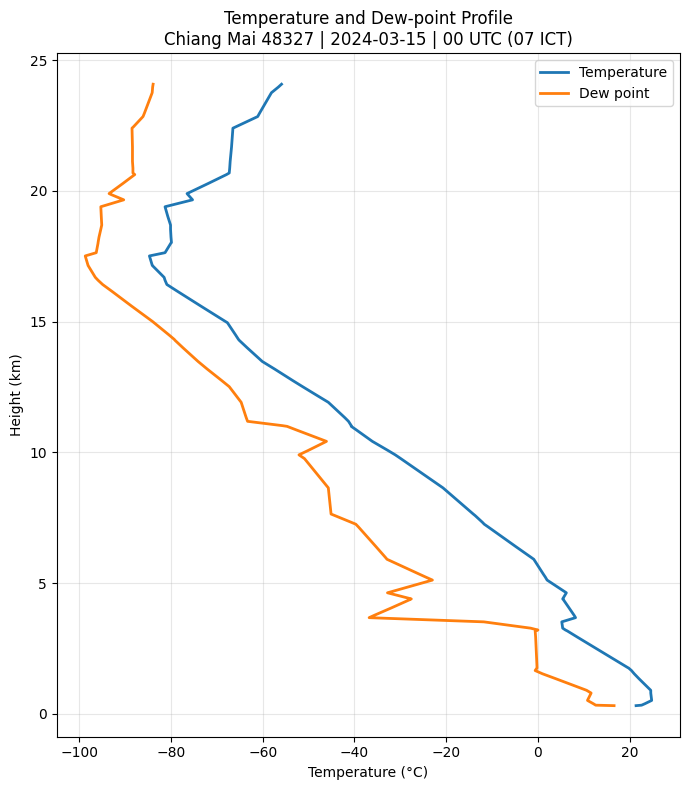

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/02_temperature_dewpoint_2024-03-15.png


In [9]:
# ================================================================
# CELL 9 — Temperature and dew-point profile
# ================================================================
plot_profile = profile[
    profile["height_m"].notna()
].copy()

fig, ax = plt.subplots(
    figsize=(7, 8)
)

ax.plot(
    plot_profile["temperature_C"],
    plot_profile["height_m"] / 1000,
    linewidth=2,
    label="Temperature"
)

ax.plot(
    plot_profile["dewpoint_C"],
    plot_profile["height_m"] / 1000,
    linewidth=2,
    label="Dew point"
)

ax.set_xlabel(
    "Temperature (°C)"
)

ax.set_ylabel(
    "Height (km)"
)

ax.set_title(
    f"Temperature and Dew-point Profile\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC (07 ICT)"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

TEMP_FIG = (
    FIG_DIR
    / f"02_temperature_dewpoint_{SELECTED_DATE}.png"
)

fig.savefig(
    TEMP_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    TEMP_FIG
)

# 2.8 Moisture Profile

เราจะดู 2 ตัวแปรร่วมกัน:

### Relative humidity

เป็นสัดส่วนความชื้นเทียบกับสภาวะอิ่มตัว ณ อุณหภูมินั้น

### Mixing ratio

เป็นปริมาณไอน้ำต่อมวลอากาศแห้ง

ในการศึกษามลพิษ ความชื้นสัมพันธ์กับ:

- aerosol hygroscopic growth
- cloud/fog processes
- wet removal
- atmospheric chemistry บางชนิด

แต่การพบ RH สูงเพียงอย่างเดียว **ไม่ได้หมายความว่า PM₂.₅ ต้องสูง**

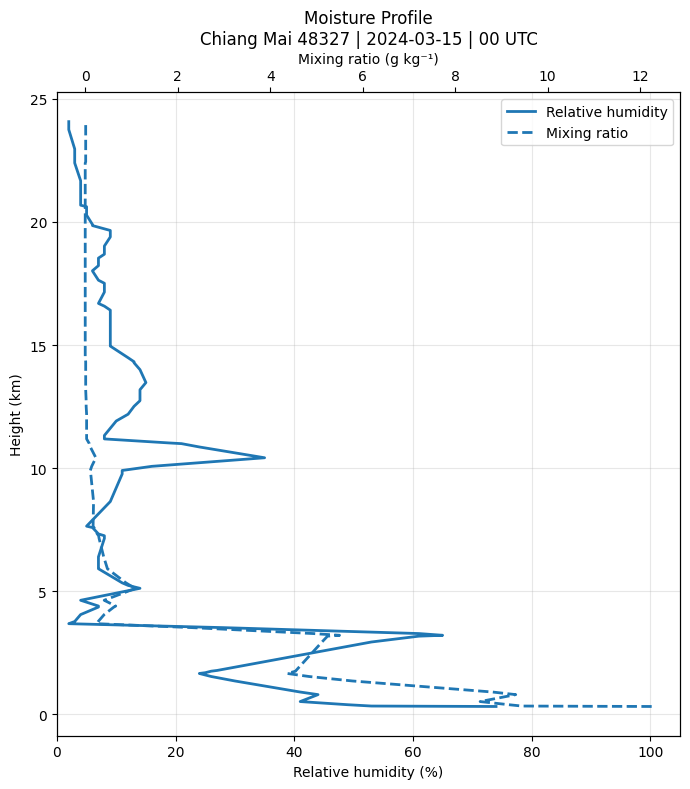

In [10]:
# ================================================================
# CELL 10 — RH and mixing-ratio profiles
# ================================================================
fig, ax1 = plt.subplots(
    figsize=(7, 8)
)

height_km = (
    profile["height_m"]
    / 1000
)

line1 = ax1.plot(
    profile["relative_humidity_pct"],
    height_km,
    linewidth=2,
    label="Relative humidity"
)

ax1.set_xlabel(
    "Relative humidity (%)"
)

ax1.set_ylabel(
    "Height (km)"
)

ax1.set_xlim(
    0,
    105
)

ax1.grid(
    alpha=0.3
)

ax2 = ax1.twiny()

line2 = ax2.plot(
    profile["mixing_ratio_gkg"],
    height_km,
    linewidth=2,
    linestyle="--",
    label="Mixing ratio"
)

ax2.set_xlabel(
    "Mixing ratio (g kg⁻¹)"
)

lines = line1 + line2

labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="upper right"
)

ax1.set_title(
    f"Moisture Profile\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC"
)

fig.tight_layout()

MOIST_FIG = (
    FIG_DIR
    / f"02_moisture_profile_{SELECTED_DATE}.png"
)

fig.savefig(
    MOIST_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2.9 Wind Profile

ลมมีบทบาทต่อคุณภาพอากาศอย่างน้อย 2 ด้าน:

1. **Advection** — ขนส่งมลพิษในแนวราบ
2. **Ventilation** — ช่วยกระจายมลพิษออกจากพื้นที่

แต่ wind speed เพียงระดับเดียวไม่เพียงพอในการอธิบาย atmospheric ventilation

ในบทต่อไปจะต้องพิจารณาลมร่วมกับ mixing height

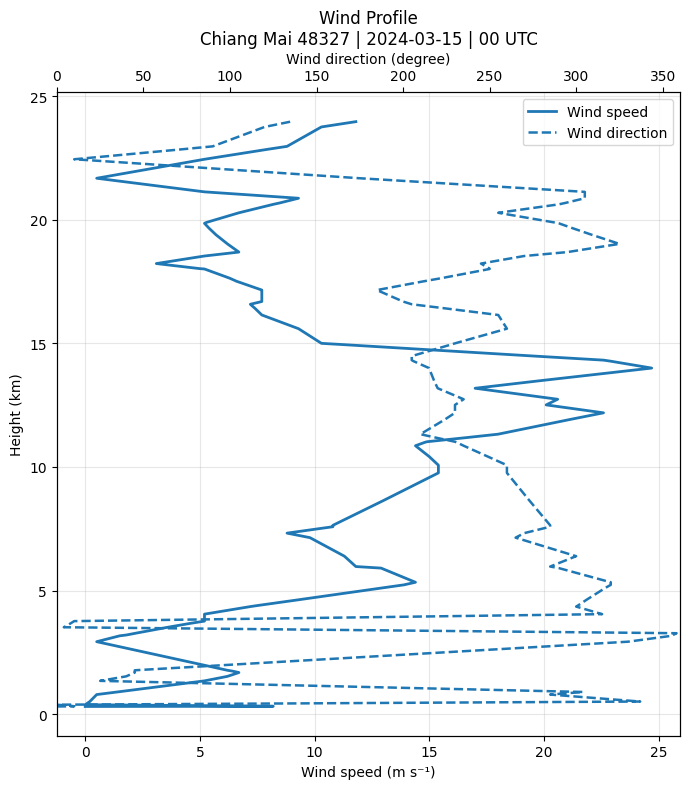

In [11]:
# ================================================================
# CELL 11 — Wind-speed and wind-direction profiles
# ================================================================
fig, ax1 = plt.subplots(
    figsize=(7, 8)
)

height_km = (
    profile["height_m"]
    / 1000
)

line1 = ax1.plot(
    profile["wind_speed_ms"],
    height_km,
    linewidth=2,
    label="Wind speed"
)

ax1.set_xlabel(
    "Wind speed (m s⁻¹)"
)

ax1.set_ylabel(
    "Height (km)"
)

ax1.grid(
    alpha=0.3
)

ax2 = ax1.twiny()

line2 = ax2.plot(
    profile["wind_direction_deg"],
    height_km,
    linewidth=1.8,
    linestyle="--",
    label="Wind direction"
)

ax2.set_xlabel(
    "Wind direction (degree)"
)

ax2.set_xlim(
    0,
    360
)

lines = line1 + line2

labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="upper right"
)

ax1.set_title(
    f"Wind Profile\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC"
)

fig.tight_layout()

WIND_FIG = (
    FIG_DIR
    / f"02_wind_profile_{SELECTED_DATE}.png"
)

fig.savefig(
    WIND_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2.10 Potential Temperature

Potential temperature นิยามโดยประมาณเป็น

\[
\theta
=
T
\left(
\frac{p_0}{p}
\right)^{R_d/c_p}
\]

โดย \(\theta\) คืออุณหภูมิที่ parcel จะมี หากนำแบบ adiabatic ไปยังความกดอากาศอ้างอิง 1000 hPa

Potential temperature มีประโยชน์ในการวิเคราะห์ static stability เพราะช่วยแยกผลของ pressure ออกจาก thermal structure

โดยทั่วไป:

\[
\frac{d\theta}{dz}>0
\]

บ่งชี้ stable stratification

\[
\frac{d\theta}{dz}\approx0
\]

ใกล้ neutral

ส่วนกรณีที่ \(\theta\) ลดลงกับความสูงสัมพันธ์กับ instability

Notebook นี้ยังไม่คำนวณ stability index โดยละเอียด แต่ให้นิสิตเริ่มสังเกตรูปร่างของ \(\theta(z)\)

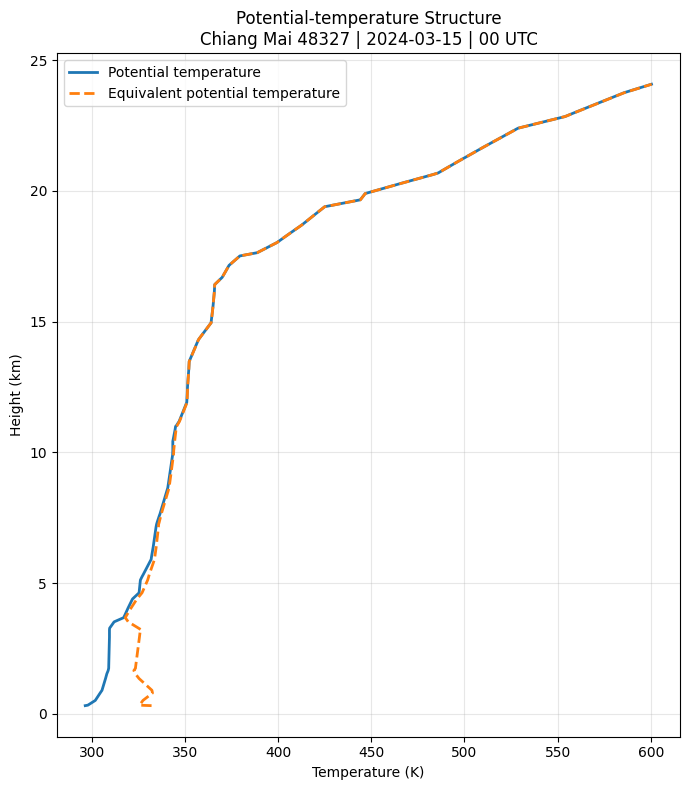

In [12]:
# ================================================================
# CELL 12 — Potential-temperature profiles
# ================================================================
fig, ax = plt.subplots(
    figsize=(7, 8)
)

ax.plot(
    profile["theta_K"],
    profile["height_m"] / 1000,
    linewidth=2,
    label="Potential temperature"
)

ax.plot(
    profile["theta_e_K"],
    profile["height_m"] / 1000,
    linewidth=2,
    linestyle="--",
    label="Equivalent potential temperature"
)

ax.set_xlabel(
    "Temperature (K)"
)

ax.set_ylabel(
    "Height (km)"
)

ax.set_title(
    f"Potential-temperature Structure\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

THETA_FIG = (
    FIG_DIR
    / f"02_theta_profile_{SELECTED_DATE}.png"
)

fig.savefig(
    THETA_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2.11 Focus on the Lower Troposphere

สำหรับคุณภาพอากาศ เรามักสนใจชั้นบรรยากาศใกล้พื้นมากกว่าชั้น stratosphere

ในขั้นนี้จะตัดข้อมูลเฉพาะ **0–3 km เหนือระดับทะเลปานกลางโดยประมาณ** เพื่อสังเกต:

- temperature
- dew point
- RH
- potential temperature
- wind

> หมายเหตุ: `height_m` ใน sounding เป็น geopotential height ไม่ใช่ความสูงเหนือพื้นสถานี (AGL) โดยตรง  
> ใน Notebook ขั้นสูงจะปรับเป็น AGL เมื่อวิเคราะห์ boundary layer

In [13]:
# ================================================================
# CELL 13 — Lower-troposphere subset
# ================================================================
LOWER_TOP_M = 3000

lower = profile[
    profile["height_m"]
    <= LOWER_TOP_M
].copy()

print(
    "Levels below or equal to 3 km:",
    len(lower)
)

display(
    lower[
        [
            "pressure_hPa",
            "height_m",
            "temperature_C",
            "dewpoint_C",
            "relative_humidity_pct",
            "wind_speed_ms",
            "theta_K"
        ]
    ]
)

Levels below or equal to 3 km: 14


,pressure_hPa,height_m,temperature_C,dewpoint_C,relative_humidity_pct,wind_speed_ms,theta_K
0,977.0,314.0,21.4,16.6,74.0,0.0,296.5
1,976.0,323.0,22.0,14.6,63.0,8.2,297.2
2,975.0,332.0,22.6,12.6,53.0,7.1,297.9
3,969.0,386.0,23.3,12.1,49.0,0.0,299.1
4,955.0,514.0,24.8,10.8,41.0,0.2,301.9
5,925.0,796.0,24.6,11.6,44.0,0.5,304.5
6,914.0,901.0,24.6,10.6,41.0,1.4,305.5
7,868.0,1350.0,22.0,3.8,30.0,5.2,307.4
8,850.0,1532.0,21.0,1.0,26.0,6.2,308.1
9,838.0,1655.0,20.4,-0.6,24.0,6.6,308.8


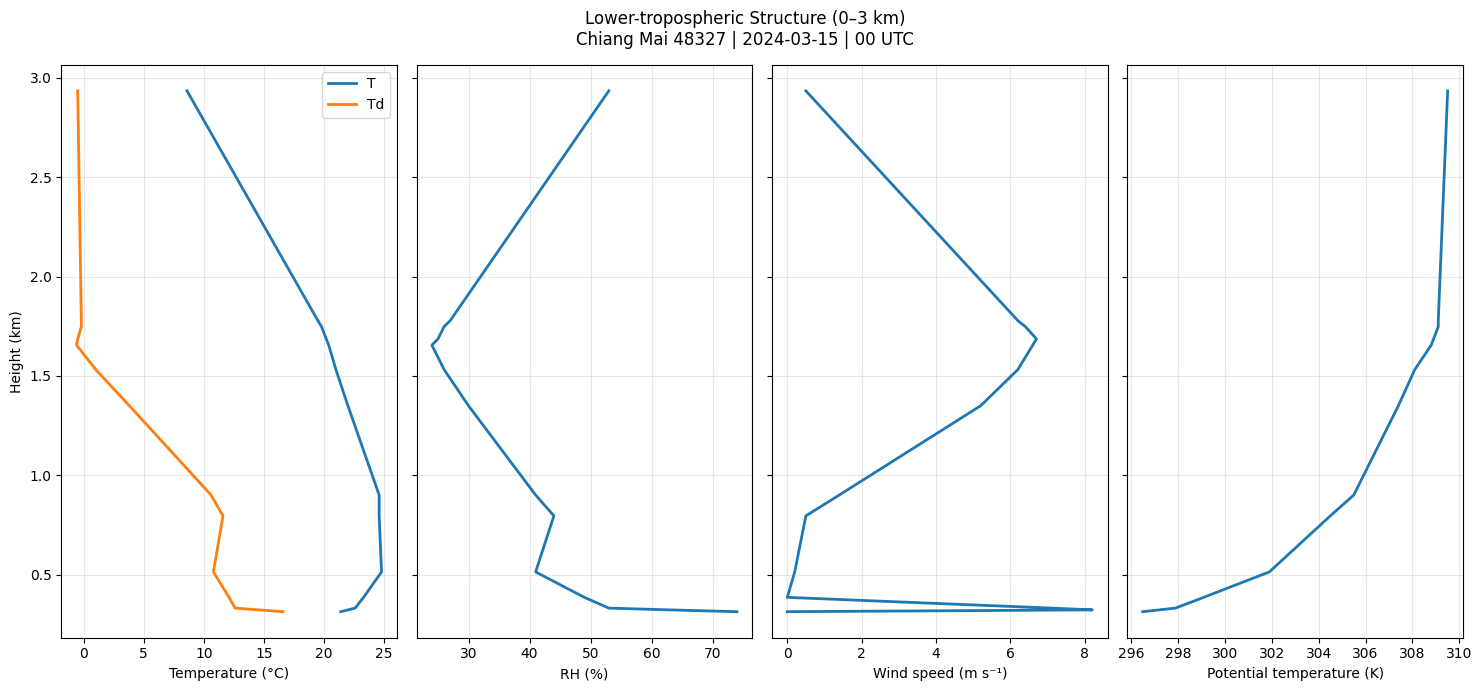

In [14]:
# ================================================================
# CELL 14 — Lower-troposphere overview figure
# ================================================================
fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(15, 7),
    sharey=True
)

height_km = (
    lower["height_m"]
    / 1000
)

axes[0].plot(
    lower["temperature_C"],
    height_km,
    linewidth=2,
    label="T"
)

axes[0].plot(
    lower["dewpoint_C"],
    height_km,
    linewidth=2,
    label="Td"
)

axes[0].set_xlabel(
    "Temperature (°C)"
)

axes[0].set_ylabel(
    "Height (km)"
)

axes[0].legend()

axes[1].plot(
    lower["relative_humidity_pct"],
    height_km,
    linewidth=2
)

axes[1].set_xlabel(
    "RH (%)"
)

axes[2].plot(
    lower["wind_speed_ms"],
    height_km,
    linewidth=2
)

axes[2].set_xlabel(
    "Wind speed (m s⁻¹)"
)

axes[3].plot(
    lower["theta_K"],
    height_km,
    linewidth=2
)

axes[3].set_xlabel(
    "Potential temperature (K)"
)

for ax in axes:
    ax.grid(
        alpha=0.3
    )

fig.suptitle(
    f"Lower-tropospheric Structure (0–3 km)\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC"
)

fig.tight_layout()

LOWER_FIG = (
    FIG_DIR
    / f"02_lower_troposphere_{SELECTED_DATE}.png"
)

fig.savefig(
    LOWER_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2.12 เปรียบเทียบ Sounding หลายวัน

การดู sounding เพียงวันเดียวอาจทำให้ตีความเหตุการณ์เฉพาะวันมากเกินไป

เราจะเปรียบเทียบตัวอย่าง 3 วัน:

- 5 March
- 25 March
- 15 April

เป้าหมายยังไม่ใช่การอธิบายเหตุการณ์ PM₂.₅ แต่เป็นการฝึกมอง atmospheric variability

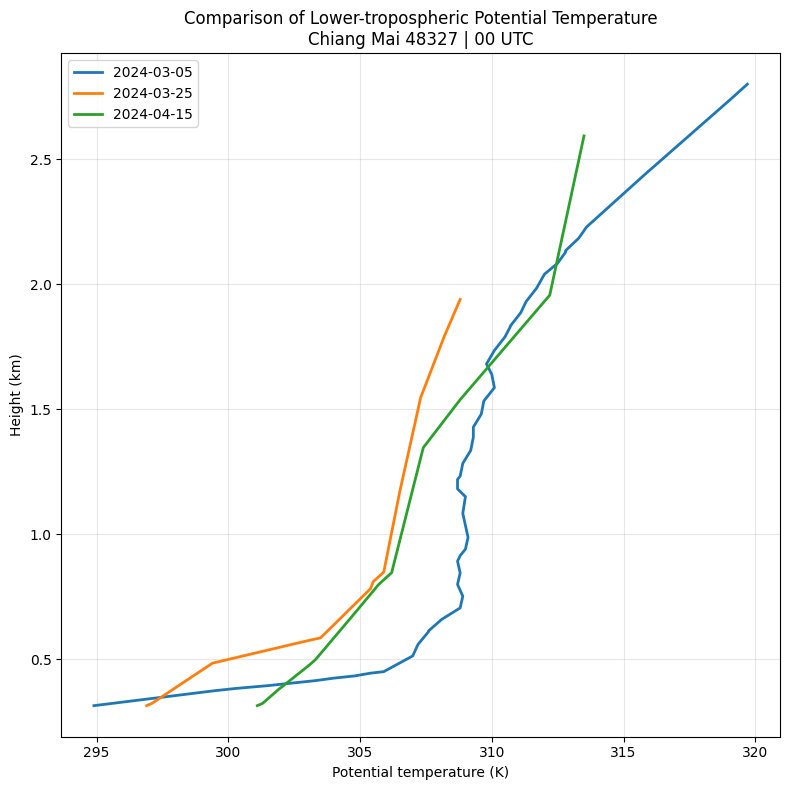

In [15]:
# ================================================================
# CELL 15 — Compare three sounding dates
# ================================================================
COMPARE_DATES = [
    "2024-03-05",
    "2024-03-25",
    "2024-04-15"
]

fig, ax = plt.subplots(
    figsize=(8, 8)
)

for date_str in COMPARE_DATES:

    p = df[
        df[
            "launch_datetime_utc"
        ]
        .dt.strftime(
            "%Y-%m-%d"
        )
        == date_str
    ].copy()

    p = p[
        p["height_m"]
        <= 3000
    ]

    ax.plot(
        p["theta_K"],
        p["height_m"] / 1000,
        linewidth=2,
        label=date_str
    )

ax.set_xlabel(
    "Potential temperature (K)"
)

ax.set_ylabel(
    "Height (km)"
)

ax.set_title(
    "Comparison of Lower-tropospheric Potential Temperature\n"
    "Chiang Mai 48327 | 00 UTC"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

COMPARE_FIG = (
    FIG_DIR
    / "02_compare_theta_three_dates.png"
)

fig.savefig(
    COMPARE_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2.13 สถิติพื้นฐานของแต่ละ Sounding

ก่อนเข้าสู่สถิติ 61 วันเต็มในบทท้าย เราจะสรุปค่าพื้นฐานต่อ sounding เช่น

- surface temperature
- surface RH
- surface wind speed
- maximum sounding height
- number of vertical levels

คำว่า “surface” ในที่นี้หมายถึง **ระดับแรกที่มีข้อมูลใน sounding** ไม่ใช่ค่าจากสถานีผิวพื้นอีกชุดหนึ่ง

In [16]:
# ================================================================
# CELL 16 — Build simple daily sounding summary
# ================================================================
daily_rows = []

for launch, p in df.groupby(
    "launch_datetime_utc"
):

    p = (
        p
        .sort_values(
            "height_m"
        )
        .copy()
    )

    first_valid = p.iloc[0]

    daily_rows.append({
        "date": launch.date(),
        "n_levels": len(p),
        "surface_pressure_hPa": first_valid["pressure_hPa"],
        "surface_temperature_C": first_valid["temperature_C"],
        "surface_dewpoint_C": first_valid["dewpoint_C"],
        "surface_RH_pct": first_valid["relative_humidity_pct"],
        "surface_wind_ms": first_valid["wind_speed_ms"],
        "max_height_m": p["height_m"].max()
    })

daily_basic = pd.DataFrame(
    daily_rows
)

print(
    "Daily summary rows:",
    len(daily_basic)
)

display(
    daily_basic.head(10)
)

print("\nBasic descriptive statistics:")

display(
    daily_basic[
        [
            "n_levels",
            "surface_pressure_hPa",
            "surface_temperature_C",
            "surface_dewpoint_C",
            "surface_RH_pct",
            "surface_wind_ms",
            "max_height_m"
        ]
    ]
    .describe()
)

Daily summary rows: 61


,date,n_levels,surface_pressure_hPa,surface_temperature_C,surface_dewpoint_C,surface_RH_pct,surface_wind_ms,max_height_m
0,2024-03-01,46,1000.0,20.8,19.8,94.0,0.0,2812.0
1,2024-03-02,53,1000.0,20.6,17.2,81.0,1.0,2850.0
2,2024-03-03,63,1000.0,22.2,17.2,73.0,0.0,2850.0
3,2024-03-04,56,1000.0,21.8,17.1,75.0,1.5,3450.0
4,2024-03-05,54,1000.0,21.8,17.8,78.0,1.0,2800.0
5,2024-03-06,99,975.0,21.4,16.4,73.0,0.0,24951.0
6,2024-03-07,87,975.0,21.0,16.4,75.0,0.0,25657.0
7,2024-03-08,69,976.0,22.0,17.5,76.0,0.0,20415.0
8,2024-03-09,81,976.0,21.0,16.0,73.0,0.0,23817.0
9,2024-03-10,74,978.0,23.0,16.0,65.0,0.0,23418.0



Basic descriptive statistics:


,n_levels,surface_pressure_hPa,surface_temperature_C,surface_dewpoint_C,surface_RH_pct,surface_wind_ms,max_height_m
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,76.885246,977.590164,24.373770,19.504918,74.573770,0.057377,21697.180328
std,12.244861,7.239652,2.511699,2.501828,5.769053,0.259781,5834.081346
min,46.000000,971.000000,20.600000,14.800000,65.000000,0.000000,2800.000000
25%,71.000000,973.000000,22.000000,17.400000,70.000000,0.000000,22249.000000
50%,77.000000,976.000000,24.400000,19.800000,74.000000,0.000000,23418.000000
75%,84.000000,978.000000,26.400000,21.500000,76.000000,0.000000,24159.000000
max,117.000000,1000.000000,29.400000,24.600000,94.000000,1.500000,25805.000000


# 2.14 บันทึกผลลัพธ์สำหรับบทต่อไป

Notebook นี้จะบันทึก:

1. ตาราง missing values
2. structural QC ของทุก sounding
3. basic daily sounding summary
4. รูป vertical profiles

เพื่อแสดงแนวคิดว่า workflow ที่ดีควรเก็บ derived products ไว้ตรวจสอบย้อนกลับได้

In [17]:
# ================================================================
# CELL 17 — Save tables (robust version)
# ================================================================

MISSING_FILE = (
    OUTPUT_DIR
    / "02_missing_data_summary.csv"
)

QC_ALL_FILE = (
    OUTPUT_DIR
    / "02_basic_QC_all_soundings.csv"
)

DAILY_BASIC_FILE = (
    OUTPUT_DIR
    / "02_daily_basic_sounding_summary.csv"
)

# ------------------------------------------------
# Safety check:
# Rebuild the all-sounding QC table if the variable
# does not exist in the current runtime.
# ------------------------------------------------
if "qc" not in globals():

    print(
        "QC table was not found in memory. "
        "Rebuilding it from df ..."
    )

    qc_rows = []

    for launch, p_profile in df.groupby(
        "launch_datetime_utc"
    ):

        p_profile = p_profile.sort_values(
            "pressure_hPa",
            ascending=False
        ).copy()

        pressure = pd.to_numeric(
            p_profile["pressure_hPa"],
            errors="coerce"
        ).dropna()

        if len(pressure) >= 2:
            pressure_monotonic = bool(
                (
                    pressure.diff()
                    .dropna()
                    <= 0
                ).all()
            )
        else:
            pressure_monotonic = False

        temperature = pd.to_numeric(
            p_profile["temperature_C"],
            errors="coerce"
        )

        dewpoint = pd.to_numeric(
            p_profile["dewpoint_C"],
            errors="coerce"
        )

        valid_td = (
            temperature.notna()
            & dewpoint.notna()
        )

        td_gt_t_count = int(
            (
                dewpoint[valid_td]
                > temperature[valid_td] + 0.2
            ).sum()
        )

        qc_rows.append({
            "launch_datetime_utc": launch,
            "n_levels": len(p_profile),
            "pressure_monotonic_decreasing": pressure_monotonic,
            "Td_gt_T_plus_0p2_count": td_gt_t_count
        })

    qc = pd.DataFrame(
        qc_rows
    )

# ------------------------------------------------
# Safety check for daily_basic
# ------------------------------------------------
if "daily_basic" not in globals():

    print(
        "Daily basic summary was not found in memory. "
        "Rebuilding it from df ..."
    )

    daily_rows = []

    for launch, p_profile in df.groupby(
        "launch_datetime_utc"
    ):

        p_profile = (
            p_profile
            .sort_values("height_m")
            .copy()
        )

        first_valid = p_profile.iloc[0]

        daily_rows.append({
            "date": launch.date(),
            "n_levels": len(p_profile),
            "surface_pressure_hPa": first_valid["pressure_hPa"],
            "surface_temperature_C": first_valid["temperature_C"],
            "surface_dewpoint_C": first_valid["dewpoint_C"],
            "surface_RH_pct": first_valid["relative_humidity_pct"],
            "surface_wind_ms": first_valid["wind_speed_ms"],
            "max_height_m": p_profile["height_m"].max()
        })

    daily_basic = pd.DataFrame(
        daily_rows
    )

# ------------------------------------------------
# Safety check for missing_summary
# ------------------------------------------------
if "missing_summary" not in globals():

    print(
        "Missing-data summary was not found in memory. "
        "Rebuilding it from df ..."
    )

    core_variables_save = [
        "pressure_hPa",
        "height_m",
        "temperature_C",
        "dewpoint_C",
        "relative_humidity_pct",
        "mixing_ratio_gkg",
        "wind_direction_deg",
        "wind_speed_ms",
        "theta_K",
        "theta_e_K",
        "theta_v_K"
    ]

    missing_summary = pd.DataFrame({
        "variable": core_variables_save,
        "missing_n": [
            df[col].isna().sum()
            for col in core_variables_save
        ],
        "total_n": [
            len(df)
            for col in core_variables_save
        ]
    })

    missing_summary["missing_pct"] = (
        100
        * missing_summary["missing_n"]
        / missing_summary["total_n"]
    )

# ------------------------------------------------
# Save all tables
# ------------------------------------------------
missing_summary.to_csv(
    MISSING_FILE,
    index=False
)

qc.to_csv(
    QC_ALL_FILE,
    index=False
)

daily_basic.to_csv(
    DAILY_BASIC_FILE,
    index=False
)

print("Saved outputs:")

print(
    " -",
    MISSING_FILE
)

print(
    " -",
    QC_ALL_FILE
)

print(
    " -",
    DAILY_BASIC_FILE
)

print("\nRows saved:")
print(
    "Missing summary :",
    len(missing_summary)
)

print(
    "QC soundings    :",
    len(qc)
)

print(
    "Daily summaries :",
    len(daily_basic)
)


QC table was not found in memory. Rebuilding it from df ...
Saved outputs:
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/02_missing_data_summary.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/02_basic_QC_all_soundings.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/02_daily_basic_sounding_summary.csv

Rows saved:
Missing summary : 11
QC soundings    : 61
Daily summaries : 61


# 2.15 แบบฝึกหัด

## Exercise 1 — เปลี่ยนวัน

เปลี่ยน

```python
SELECTED_DATE = "2024-03-15"
```

เป็นวันอื่นอย่างน้อย 3 วัน แล้วเปรียบเทียบ

- temperature profile
- moisture profile
- wind profile
- potential temperature

---

## Exercise 2 — ชั้นบรรยากาศใกล้พื้น

เปลี่ยน

```python
LOWER_TOP_M = 3000
```

เป็น

```python
LOWER_TOP_M = 1500
```

แล้วพิจารณาว่าภาพของ lower-atmosphere structure เปลี่ยนไปอย่างไร

---

## Exercise 3 — Missing data

เลือกตัวแปรที่มี missing percentage สูงสุด แล้วตรวจว่า missing values กระจาย:

- อยู่เฉพาะชั้นบน?
- อยู่เฉพาะบางวัน?
- หรือกระจายทั่ว profile?

---

## Exercise 4 — Air-quality interpretation

เลือก 2 วันที่ potential temperature ในชั้นล่างมีลักษณะแตกต่างกัน แล้วตอบ:

1. วันใดดูมี stable layer ชัดกว่า?
2. หาก emissions เท่ากัน วันใดอาจมีเงื่อนไขเอื้อต่อการสะสมมลพิษใกล้พื้นมากกว่า?
3. มีข้อมูลใดที่ยังขาดก่อนจะสรุปเกี่ยวกับ PM₂.₅ จริง?

คำตอบข้อ 3 ควรพิจารณาอย่างน้อย:

- actual PM₂.₅ concentration
- emissions
- surface meteorology
- boundary-layer depth
- regional transport

---

# สิ่งที่ควรจำจาก Notebook 02

1. Sounding เป็นข้อมูล vertical profile ไม่ใช่ surface observation อย่างเดียว
2. Pressure ลดลงตามความสูง
3. \(T\), \(T_d\), RH และ mixing ratio ใช้อธิบาย thermal-moisture structure
4. Wind profile มีความสำคัญต่อ pollutant transport
5. Potential temperature ช่วยอธิบาย atmospheric stability
6. Missing values ควรถูกตรวจและ flag ก่อนลบ
7. ข้อมูล 00 UTC ของเชียงใหม่คือประมาณ 07:00 ICT จึงเป็น morning atmospheric structure

---

# Notebook ต่อไป

## `03_SkewT_and_atmospheric_thermodynamics.ipynb`

จะเริ่มเรียน:

- Skew-T Log-P
- dry adiabats
- moist adiabats
- parcel profile
- LCL
- LFC
- EL
- CAPE
- CIN
- precipitable water

โดยใช้ข้อมูลชุดเดียวกันจาก Google Drive